In [1]:
import math
from pathlib import Path
import cvxpy as cp
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

from mis_dro.dataset import get_portfolio_returns_df
from mis_dro.experiments import ExperimentName
from mis_dro.constants import IN_SAMPLE_TIME_WINDOW, OUT_OF_SAMPLE_TIME_WINDOW
from mis_dro.plot import *

In [2]:
mmc2_dir = Path("/dcs/pg20/u1508153/datasets/misdro/mmc2")
assert mmc2_dir.exists()
dgp = "DowJones"
returns_df = get_portfolio_returns_df(mmc2_dir, "DowJones-crash")
index_returns_df = pd.read_excel(mmc2_dir / "Datasets" / "DowJones" / f"DowJones.xlsx", sheet_name="Index_Returns", header=None)

In [3]:
experiment_name = ExperimentName.kl_portfolio_crash
experiment_dir = Path("/dcs/large/u1508153/misdro/bas_crash")
assert experiment_dir.exists()
all_results_df = pd.read_csv(experiment_dir / "results.csv", index_col=["uuid", "replication"])

# add RoBAS results too
robas_results = pd.read_csv("/dcs/large/u1508153/misdro/robas_crash/results.csv", index_col=["uuid", "replication"])
all_results_df = pd.concat([all_results_df, robas_results])

all_results_df["algorithm"].unique()


array(['kl_dro_bas', 'kl_bdro', 'kl_pp', 'dro_bas_mmd', 'empirical_mmd'],
      dtype=object)

In [4]:
results_df = preprocess_results_df(all_results_df, "DowJones-crash", dataset="portfolio")
agg_df = get_agg_df(results_df, gb_cols=["algorithm", "epsilon", "inference"])
agg_df

/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/plot.py:199: FutureWarning: The provided callable <function mean at 0x7fa9500863e0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/plot.py:199: FutureWarning: The provided callable <function std at 0x7fa950086520> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  agg_df = gb.agg(


out_of_sample_mean  out_of_sample_var  \
algorithm   epsilon inference                                          
dro_bas_mmd 0.0001  npl_mmd             -0.004919           0.003953   
            0.0010  npl_mmd             -0.004919           0.003953   
            0.0050  npl_mmd             -0.002843           0.004222   
            0.0100  npl_mmd             -0.003158           0.003259   
            0.0500  npl_mmd             -0.004188           0.003159   
...                                           ...                ...   
kl_pp       0.0500  bayes               -0.003383           0.002635   
            0.1000  bayes               -0.003761           0.002580   
            0.2000  bayes               -0.004081           0.002549   
            0.5000  bayes               -0.004386           0.002527   
            1.0000  bayes               -0.004581           0.002528   

                               sum_of_in_group_var  var_of_in_group_mean  \
algorithm   epsilon inference                                              
dro_bas_mmd 0.0001  npl_mmd               0.003953                   NaN   
            0.0010  npl_mmd               0.003953                   NaN   
            0.0050  npl_mmd               0.004222                   NaN   
            0.0100  npl_mmd               0.003259                   NaN   
            0.0500  npl_mmd               0.003159                   NaN   
...                                            ...                   ...   
kl_pp       0.0500  bayes                 0.002635                   NaN   
            0.1000  bayes                 0.002580                   NaN   
            0.2000  bayes                 0.002549                   NaN   
            0.5000  bayes                 0.002527                   NaN   
            1.0000  bayes                 0.002528                   NaN   

                               mean_solve_time  std_solve_time  \
algorithm   epsilon inference                                    
dro_bas_mmd 0.0001  npl_mmd         201.670409             NaN   
            0.0010  npl_mmd         198.514785             NaN   
            0.0050  npl_mmd         201.562591             NaN   
            0.0100  npl_mmd         203.432327             NaN   
            0.0500  npl_mmd         203.732305             NaN   
...                                        ...             ...   
kl_pp       0.0500  bayes             0.213156             NaN   
            0.1000  bayes             0.219890             NaN   
            0.2000  bayes             0.220009             NaN   
            0.5000  bayes             0.230274             NaN   
            1.0000  bayes             0.234879             NaN   

                               mean_sample_time  std_sample_time  
algorithm   epsilon inference                                     
dro_bas_mmd 0.0001  npl_mmd            0.070949              NaN  
            0.0010  npl_mmd            0.073678              NaN  
            0.0050  npl_mmd            0.071000              NaN  
            0.0100  npl_mmd            0.071388              NaN  
            0.0500  npl_mmd            0.071314              NaN  
...                                         ...              ...  
kl_pp       0.0500  bayes              0.020279              NaN  
            0.1000  bayes              0.022512              NaN  
            0.2000  bayes              0.021839              NaN  
            0.5000  bayes              0.022153              NaN  
            1.0000  bayes              0.019310              NaN  

[64 rows x 8 columns]

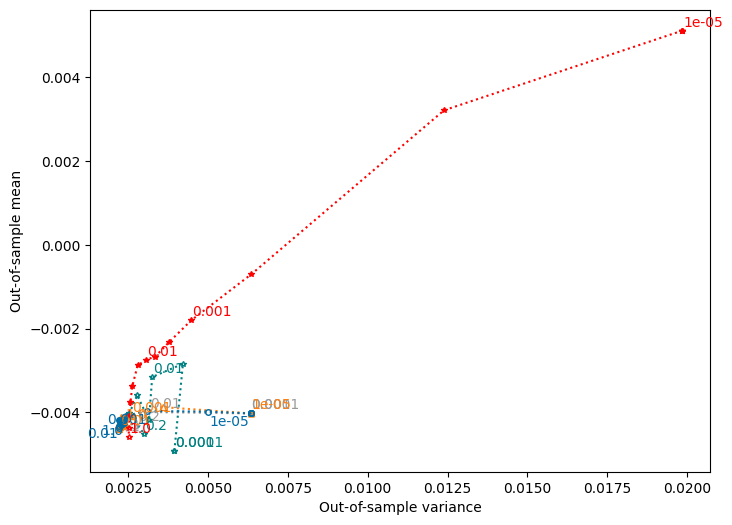

In [5]:
log_partition_constant = results_df.loc[results_df["algorithm"] == "kl_dro_bas"]["log_partition_constant"].unique()[0]
fig, ax = plt.subplots(figsize=(8,6))
df = agg_df
df.loc[:, "is_pareto_front"] = is_maximise_pareto_front(df["out_of_sample_var"].values, df["out_of_sample_mean"].values)
for (algorithm, inference), group_df in df.groupby(["algorithm", "inference"]):
    if algorithm == "kl_dro_bas":
        local_log_partition_constant = log_partition_constant
    else:
        local_log_partition_constant = 0
    mean_variance_plot(ax, group_df, is_labelled=True, offset=0.00003, alpha=1.0, **algorithm_inference_style(algorithm, inference), special_epsilons=[0.00001, 0.001, 0.01, 1.0])
ax.set_xlabel("Out-of-sample variance")
ax.set_ylabel("Out-of-sample mean")
fig.show()

In [6]:
num_replications = results_df["num_replications"].unique()[0]
out_of_sample_time_window = IN_SAMPLE_TIME_WINDOW
num_time_windows = 1
num_stocks = int(len(returns_df.columns))
bdro_labelled = False
dro_bas_labelled = False
training_time_window_id = 75
oos_week_numbers = [training_time_window_id * OUT_OF_SAMPLE_TIME_WINDOW + IN_SAMPLE_TIME_WINDOW + i for i in range(out_of_sample_time_window)]
last_week = oos_week_numbers[len(oos_week_numbers)-1]

start_training_week = training_time_window_id * OUT_OF_SAMPLE_TIME_WINDOW # inclusive
end_training_week = start_training_week + IN_SAMPLE_TIME_WINDOW # not inclusive
test_start = end_training_week
test_end = test_start + out_of_sample_time_window

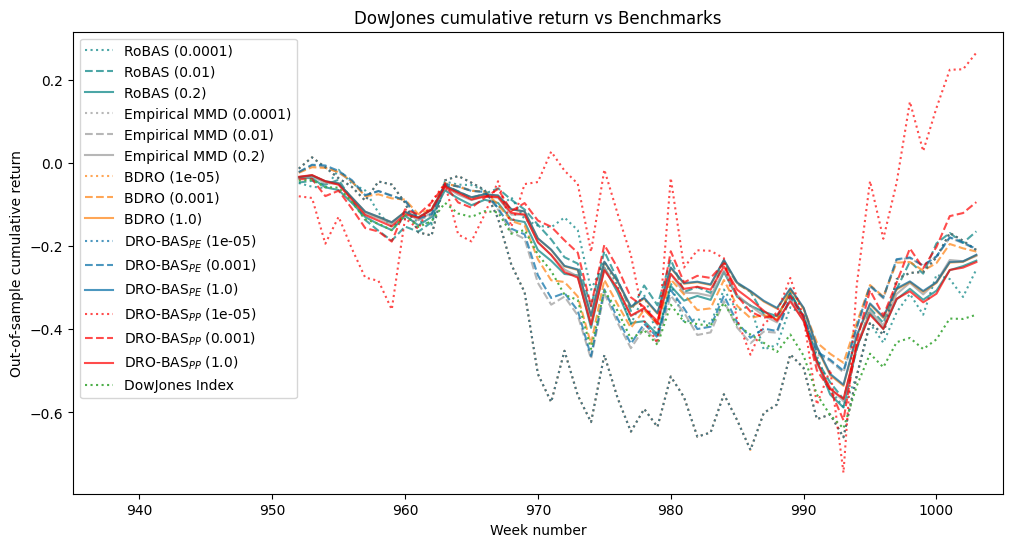

In [7]:
fig, ax = plt.subplots(figsize=(12,6))

epsilon_list = [0.00001, 0.001, 1.0]
robas_epsilon_list = [0.0001, 0.01, 0.2]
line_styles = ["dotted" , "dashed" , "solid"]

for (algorithm, epsilon), group_df in results_df.groupby(["algorithm", "epsilon"]):
    # dro_returns = group_df[week_cols].values.flatten()
    # assert OUT_OF_SAMPLE_TIME_WINDOW * num_time_windows == len(group_df) * len(group_df["out_of_sample_cost"].values[0])
    cost_list = []
    for i in range(num_replications):
        cost_list += group_df["out_of_sample_cost"].values[i]
    dro_returns = np.array(cost_list)
    # if not dro_bas_labelled and algorithm == "kl_dro_bas":
    #     label = AlgorithmName[algorithm].value
    #     dro_bas_labelled = True
    # elif not bdro_labelled and algorithm == "kl_bdro":
    #     label = AlgorithmName[algorithm].value
    #     bdro_labelled = True
    # else:
    #     label='_nolegend_'
    is_robas_experiment = algorithm in ("dro_bas_mmd", "empirical_mmd")
    label = AlgorithmName[algorithm].value + f" ({epsilon})"
    if (epsilon in epsilon_list and not is_robas_experiment) or (epsilon in robas_epsilon_list and is_robas_experiment):
        idx = robas_epsilon_list.index(epsilon) if is_robas_experiment else epsilon_list.index(epsilon)
        ax.plot(oos_week_numbers, np.cumsum(dro_returns), label=label, alpha=0.7, color=AlgorithmColor[algorithm].value, linestyle=line_styles[idx])
    # if algorithm == "kl_dro_bas" and epsilon in epsilon_list:
    #     ax.text(last_week, np.cumsum(dro_returns)[test_end-4-end_training_week], np.round(log_partition_constant + epsilon, 5), color=AlgorithmColor[algorithm].value)
    # elif algorithm == "kl_bdro" and  epsilon in [0.00002, 0.001, 0.01]:
    #     ax.text(last_week, np.cumsum(dro_returns)[last_week-4-end_training_week]-0.1, epsilon, color=AlgorithmColor[algorithm].value)

CB_color_cycle = ['#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']
ax.plot(oos_week_numbers, np.cumsum(index_returns_df.iloc[test_start:test_end].values), label=f"{dgp} Index", color=CB_color_cycle[0], linestyle="dotted")
# for baseline_model in ["CZeSD", "KP_SSD", "L_SSD", "LR_ASSD", "MeanVar", "RMZ_SSD"]:

for i, baseline_model in enumerate(["MeanVar"]):
    baseline_model_label = baseline_model if baseline_model != "MeanVar" else "Markowitz"
    baseline_portfolio_txt = mmc2_dir / "Solutions" / dgp / f"OptPortfolios_{baseline_model}_{dgp}.txt"
    baseline_portfolio = np.loadtxt(baseline_portfolio_txt).T[:num_time_windows, :]
    baseline_returns_txt = mmc2_dir / "Solutions" / dgp / f"OutofSamplePortReturns_{baseline_model}_{dgp}_List.txt" 
    baseline_returns = np.loadtxt(baseline_returns_txt)
    # ax.plot(oos_week_numbers, np.cumsum(baseline_returns[test_start-IN_SAMPLE_TIME_WINDOW:test_end-IN_SAMPLE_TIME_WINDOW]), label=baseline_model_label, color=CB_color_cycle[i+1])

ax.set_xlabel("Week number")
ax.set_ylabel("Out-of-sample cumulative return")
# ax.set_xlim(2000)
ax.set_xlim(935, 1005)
# ax.set_ylim(-0.1, 9.5)
# ax.vlines(52, -0.3, 6.9, color="black", linestyle=":")
ax.set_title(dgp + r" cumulative return vs Benchmarks")
handles, labels = ax.get_legend_handles_labels()
order = [1,0,2,3]
# ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order])
ax.legend(loc='upper left')
# plt.savefig(f"/Users/patrick/Experiments/misdro/paper_bas_figures/{experiment_name}_cum_returns_{filter_dgp}.pdf", bbox_inches="tight")

fig.show()

In [8]:
def sharp_ratio(returns, risk_free_rate: float = 0.02):
    return (np.sum(returns) - risk_free_rate) / np.std(returns)

In [9]:
np.sum(results_df["out_of_sample_cost"].iloc[30])

-0.22204776314544714

In [12]:
pretty_df = results_df.loc[
    (
        (results_df["epsilon"].isin(robas_epsilon_list)) & (results_df["algorithm"].isin(["empirical_mmd", "dro_bas_mmd"]))
        | (results_df["epsilon"].isin(epsilon_list)) & (results_df["algorithm"].isin(["kl_dro_bas", "kl_bdro", "kl_pp"]))
    )
]
pretty_df["sharp_ratio"] = pretty_df["out_of_sample_cost"].apply(sharp_ratio)
pretty_df["algorithm"] = pretty_df["algorithm"].apply(lambda x: AlgorithmName[x].value)
pretty_df[["algorithm", "epsilon", "sharp_ratio"]].set_index(["algorithm", "epsilon"])

/tmp/dcs-tmp.u1508153/ipykernel_534353/1558945030.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pretty_df["sharp_ratio"] = pretty_df["out_of_sample_cost"].apply(sharp_ratio)
/tmp/dcs-tmp.u1508153/ipykernel_534353/1558945030.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pretty_df["algorithm"] = pretty_df["algorithm"].apply(lambda x: AlgorithmName[x].value)


sharp_ratio
algorithm      epsilon             
DRO-BAS$_{PE}$ 0.00001    -2.910878
               0.00100    -4.107333
               1.00000    -4.964919
BDRO           0.00001    -2.910921
               0.00100    -4.597165
               1.00000    -4.976319
DRO-BAS$_{PP}$ 0.00001     1.761927
               0.00100    -1.717269
               1.00000    -5.186468
RoBAS          0.00010    -4.428606
               0.01000    -3.258332
               0.20000    -4.695986
Empirical MMD  0.00010    -2.910878
               0.01000    -4.081821
               0.20000    -4.657780